/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64468/1986372024.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_df_cleaned['species_sex'] = penguins_df_cleaned['species'] + ' ' + penguins_df_cleaned['sex']
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64468/1986372024.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='species_sex', y=attr, data=penguins_df_cleaned,
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64468/1986372024.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

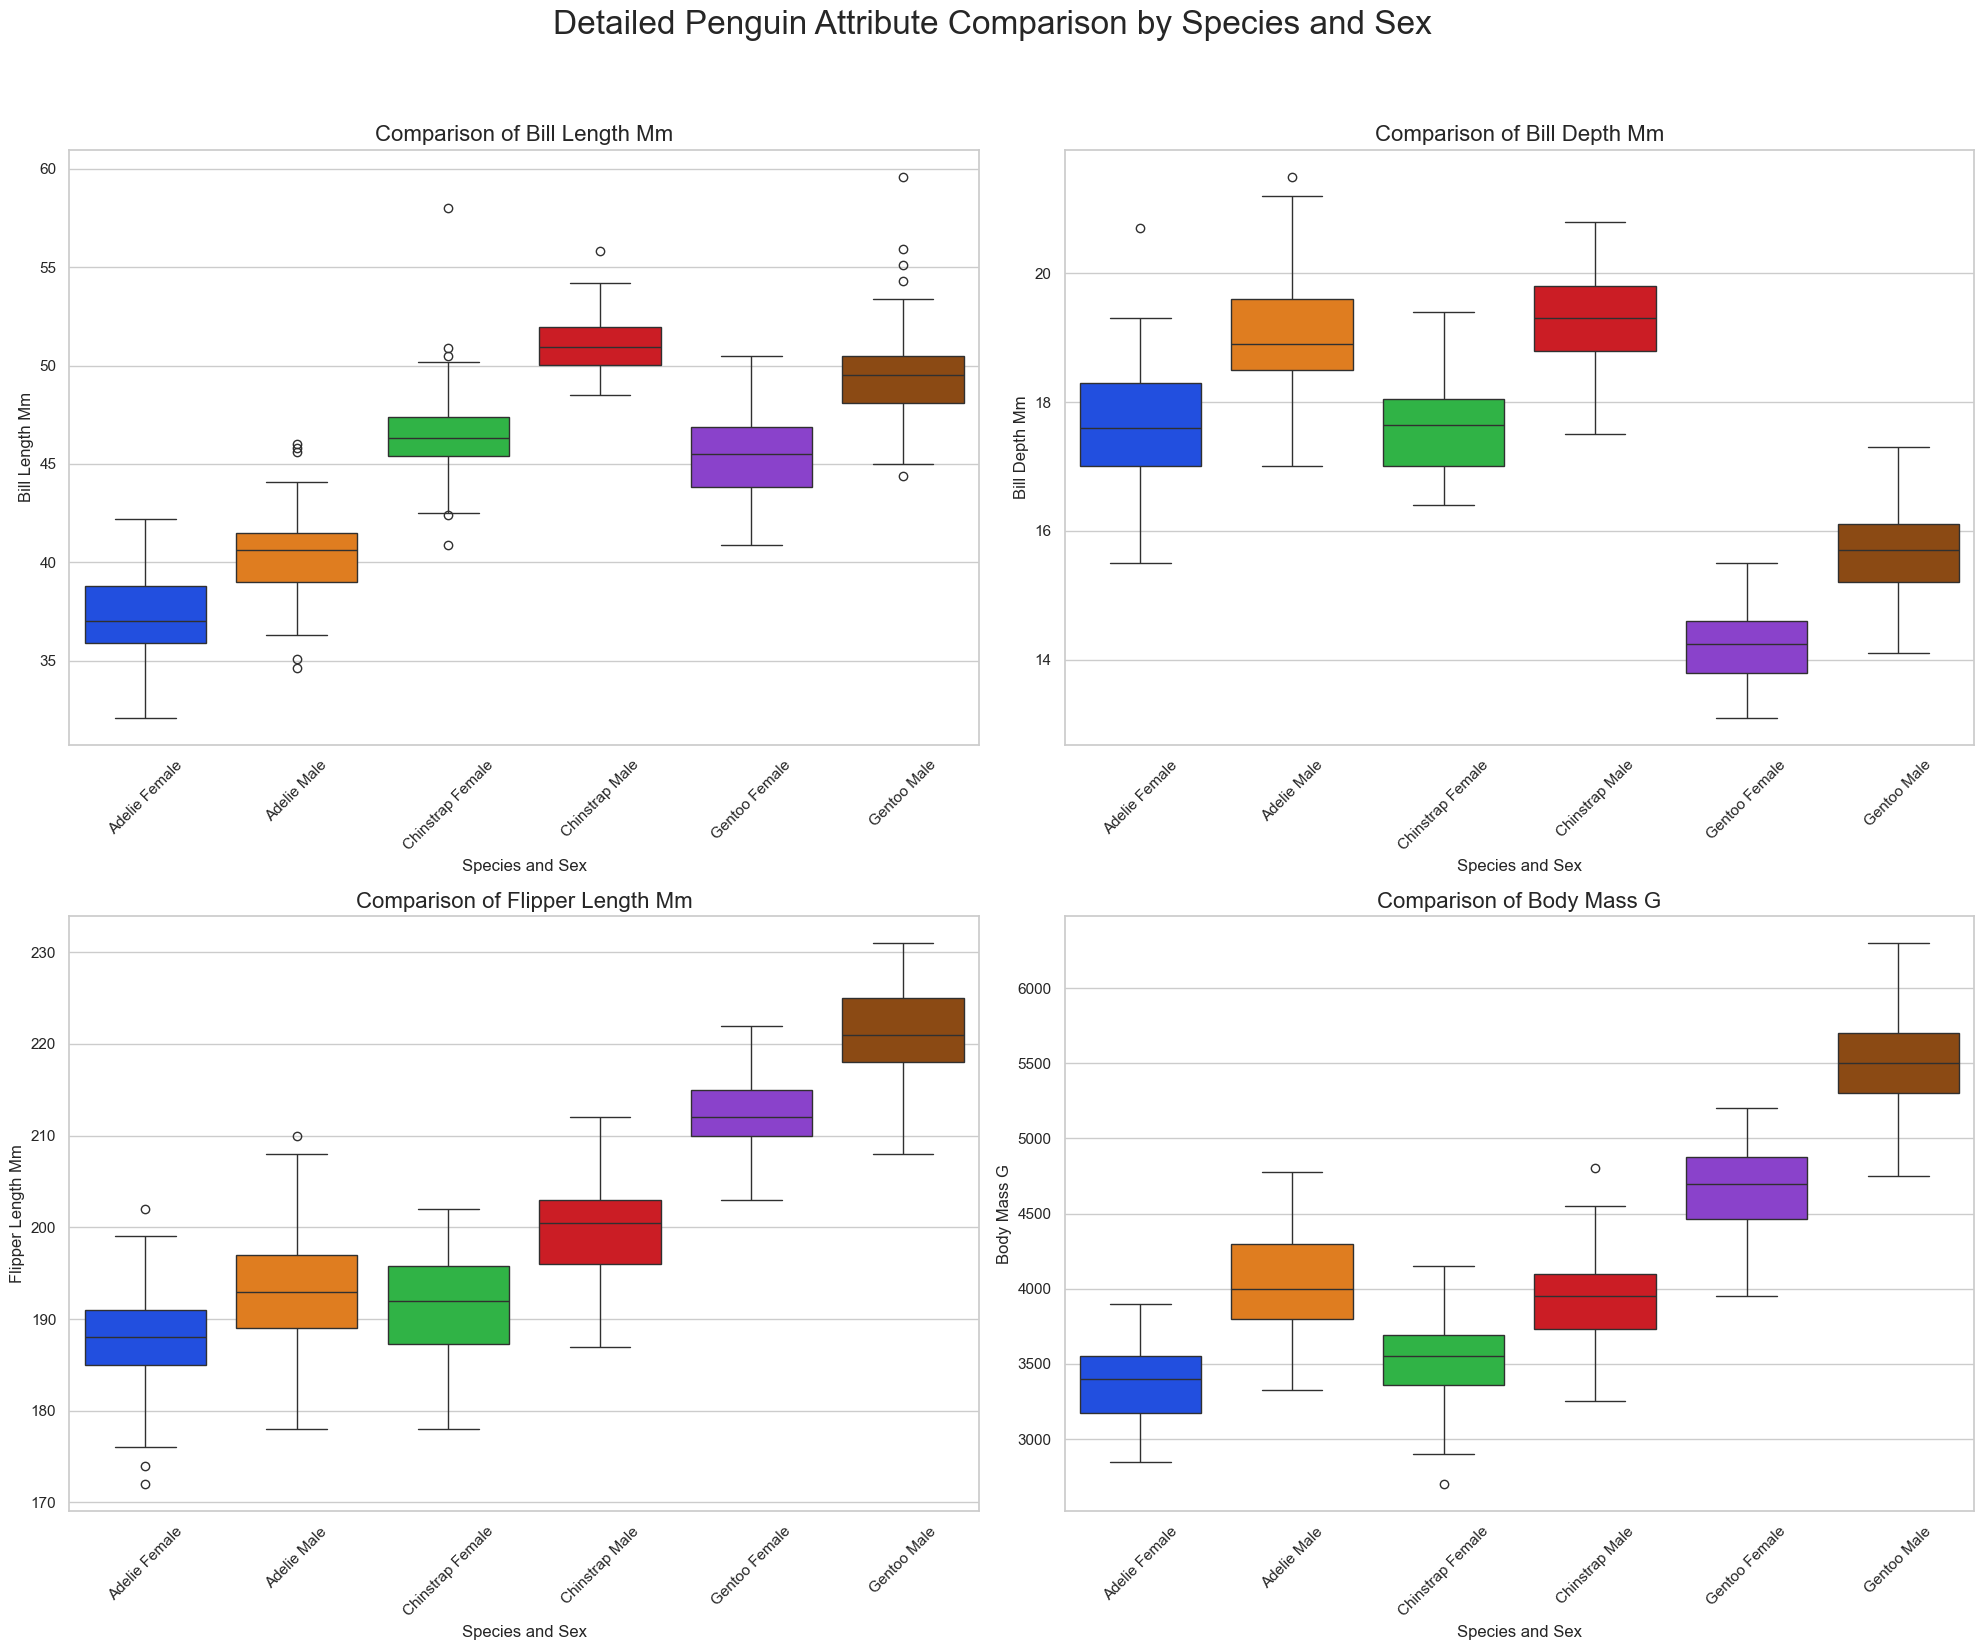

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Load and Prepare Data ---
# Load the penguins dataset from seaborn
penguins_df = sns.load_dataset("penguins")

# Drop rows with any missing data (especially in 'sex') to ensure clean plots
penguins_df_cleaned = penguins_df.dropna()

# --- 2. Create a Combined Column for Detailed Grouping ---
# This is the key step: create a new column that combines species and sex
# for use on the x-axis of our plot.
penguins_df_cleaned['species_sex'] = penguins_df_cleaned['species'] + ' ' + penguins_df_cleaned['sex']

# --- 3. Visualize the Detailed Comparison ---
# Set a clean style for the plots
sns.set_theme(style="whitegrid")

# List of the numerical attributes we want to compare
numeric_attributes = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Create a figure and a set of subplots (2 rows, 2 columns) for a neat layout
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Flatten the 2x2 array of axes to make it easy to loop through
axes = axes.flatten()

# Loop through each attribute and create a detailed box plot on its own subplot
for i, attr in enumerate(numeric_attributes):
    # Create the boxplot on the current axis (axes[i])
    sns.boxplot(ax=axes[i], x='species_sex', y=attr, data=penguins_df_cleaned,
                order=sorted(penguins_df_cleaned['species_sex'].unique()), # Sort the x-axis for consistency
                palette='bright') # Use a bright palette to distinguish groups

    # Set a clear title and labels for each subplot
    axes[i].set_title(f'Comparison of {attr.replace("_", " ").title()}', fontsize=16)
    axes[i].set_xlabel('Species and Sex', fontsize=12)
    axes[i].set_ylabel(attr.replace("_", " ").title(), fontsize=12)

    # Rotate the x-axis labels to prevent them from overlapping
    axes[i].tick_params(axis='x', rotation=45)

# Add a main, descriptive title for the entire figure
fig.suptitle('Detailed Penguin Attribute Comparison by Species and Sex', fontsize=24, y=1.03)

# Adjust layout automatically to prevent titles and labels from clashing
plt.tight_layout()

# Display the final plot
plt.show()